# Error-driven Payoff and Fairness

In [1]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import MaxNLocator

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer, Experiment
from Classes.cognitive_model_agents import (
    FairnessM1, FairnessM2, FRAplus
)

In [ ]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate":0.2,
	"bias":1,
	"forget":0.1,
    "individual_threshold":0.1,
	"inverse_temperature":16,
}
thres = [0.1, 0.25, 0.5]
agents = [
    FairnessM1(
		free_parameters=free_parameters,
		fixed_parameters=fixed_parameters,
	) for _ in range(len(thres))
]
for agent, thr in zip(agents, thres):
	agent.number = 0
	agent.individual_threshold = thr

actions = [0] * 5 + [1] * 5 + [0] * 5 + [1] * 5
num_rounds = len(actions)
probabilities = np.zeros((len(agents), num_rounds))

for i, action in enumerate(actions):
	obs_state = [action] + [1] * (fixed_parameters['num_agents'] - 1)
	for j, agent in enumerate(agents):
		payoff = agent.payoff(action, obs_state)
		power_ = agent._get_G(obs_state)
		prob = agent.go_probability()
		probabilities[j, i] = prob
		if agent.debug:
			print("")
			print("="*60)
		agent.update(payoff, obs_state)

df = pd.DataFrame({
	"individual_threshold": np.array([[j] * num_rounds for j in thres]).flatten(),
	"round": np.array([list(range(1, num_rounds + 1)) for j in thres]).flatten(),
	"probability": probabilities.flatten()
})

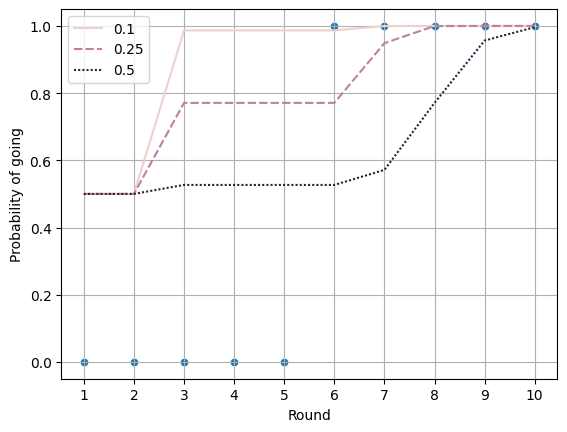

In [3]:
ax = sns.lineplot(
    x="round", y="probability", 
	hue="individual_threshold",
    style="individual_threshold",
	data=df
)
sns.scatterplot(
    x=range(1, len(actions) + 1), y=agent.decisions
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.grid()
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Round")
ax.set_ylabel("Probability of going")
ax.set_label("Individual threshold")

In [4]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate":0.2,
	"bias":1,
    "individual_threshold":0.5,
	"inverse_temperature":16,
}
simulation_parameters = {
	'num_episodes':50,
	'num_rounds':100,
	'verbose':False
}

exp = Experiment(
    agent_class=FairnessM1,
    free_parameters=free_parameters,
    fixed_parameters=fixed_parameters,
    simulation_parameters=simulation_parameters,
    measures=['bounded_efficiency', 'gini_index', 'entropy']
)

exp.run_sweep2(
    parameter1="bias",
    values1=[0, 0.2, 0.5, 0.7],
    parameter2="individual_threshold",
    values2=[0.1, 0.25, 0.5, 0.7]
)

KeyError: 'forget'

In [ ]:
gm = GetMeasurements(
    data=exp.data,
    measures=exp.measures
)
df_measures = gm.get_measurements()

In [ ]:
df_measures['bias'] = df_measures['model'].apply(
    lambda x: x.split(',')[0].split('=')[-1]
)
df_measures['bias'] = df_measures['bias'].astype(float)
df_measures['individual_threshold'] = df_measures['model'].apply(
    lambda x: x.split(',')[1].split('=')[-1]
)
df_measures['individual_threshold'] = df_measures['individual_threshold'].astype(float)

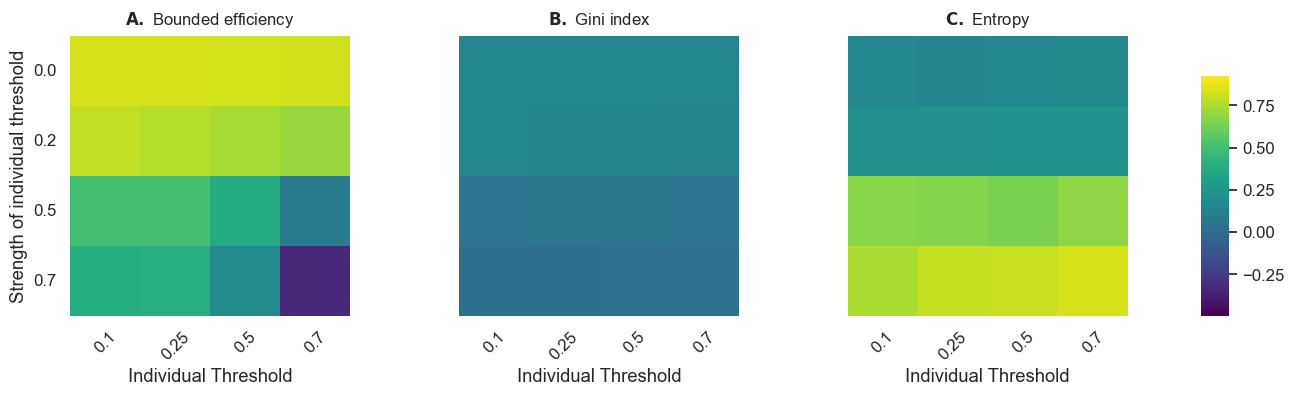

In [ ]:
sns.set_theme(style="white", font_scale=1.1)

variables = ["bounded_efficiency", "gini_index", "entropy"]
titles = [r"$\bf{A.}$ Bounded efficiency",
          r"$\bf{B.}$ Gini index",
          r"$\bf{C.}$ Entropy"]

# Compute global color scale
vmin = df_measures[variables].min().min()
vmax = df_measures[variables].max().max()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)

# Create a separate axis for a single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])

for i, (ax, var, title) in enumerate(zip(axes, variables, titles)):
    pivot = pd.pivot_table(
        data=df_measures,
        index='bias',
        columns='individual_threshold',
        values=var
    )
    
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=(i == 0),
        cbar_ax=cbar_ax if i == 0 else None,
        square=True,
        linewidths=0,   # remove gridlines for cleaner look
    )
    
    ax.set_title(title, fontsize=12, pad=8)
    
    # Only left plot keeps y-labels
    if i == 0:
        ax.set_ylabel("Strength of individual threshold")
    else:
        ax.set_ylabel("")
        # ax.set_yticklabels([])
    
    ax.set_xlabel("Individual Threshold")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# Tighten layout manually (since we added custom cbar axis)
fig.subplots_adjust(left=0.08, right=0.9, bottom=0.2, top=0.9, wspace=0.05)

plt.savefig("figure.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
mask1 = df_measures['bias'].isin([0, 0.5])
mask2 = df_measures['individual_threshold'].isin([0.25])
df = df_measures[mask1 & mask2]


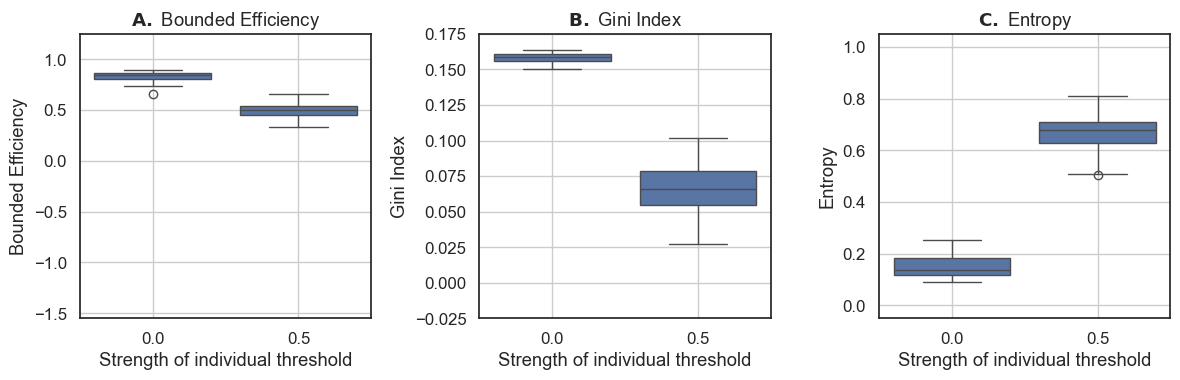

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

sns.boxplot(
    data=df,
    x="bias",
    y="bounded_efficiency",
    ax=ax[0],
)
ax[0].set_ylim(-1.55, 1.25)
ax[0].set_title(r"$\bf{A.}$ Bounded Efficiency")
ax[0].set_xlabel("Strength of individual threshold")
ax[0].set_ylabel("Bounded Efficiency")

sns.boxplot(
    data=df,
    x="bias",
    y="gini_index",
    ax=ax[1],
)
ax[1].set_ylim(-0.025, 0.175)
ax[1].set_title(r"$\bf{B.}$ Gini Index")
ax[1].set_xlabel("Strength of individual threshold")
ax[1].set_ylabel("Gini Index")

sns.boxplot(
    data=df,
    x="bias",
    y="entropy",
    ax=ax[2],
)
ax[2].set_ylim(-0.05, 1.05)
ax[2].set_title(r"$\bf{C.}$ Entropy")
ax[2].set_xlabel("Strength of individual threshold")
ax[2].set_ylabel("Entropy")

for ax_ in ax:
    ax_.grid()

fig.tight_layout()
plt.show()

In [ ]:
from Classes.parameter_recovery import ParameterFit

# Load data into a dataframe
all_data = False
two_player = False  # Set to True for 2-player UR experiment, False for multi-player IU experiment

if all_data:
    file_name = 'all_data.csv' # <= Data from all experiments combined
    best_fits_file = PATHS['parameter_fit_results'] / Path('fit_fariness.json')
elif two_player:
	file_name = '2-player-UR.csv' # <= Data from 2-player UR experiment
	best_fits_file = PATHS['parameter_fit_results'] / Path('fit_fariness_2P.json')
else:
	# file_name = '3-player-IU.csv ' # <= Data from 3-player IU experiment
	# file_name = '4-player-IU.csv' # <= Data from 3-player IU experiment
	# file_name = '5-player-IU.csv' # <= Data from 3-player IU experiment
	# file_name = '6-player-IU.csv' # <= Data from 3-player IU experiment
	file_name = '7-player-IU.csv' # <= Data from 3-player IU experiment
	# file_name = '8-player-IU.csv' # <= Data from 3-player IU experiment
	# file_name = '9-player-IU.csv' # <= Data from 3-player IU experiment
	# file_name = '11-player-IU.csv' # <= Data from 3-player IU experiment
	# file_name = '12-player-IU.csv' # <= Data from 3-player IU experiment
	# file_name = 'multi-player.csv' # <= Data from multi-player IU experiment
	best_fits_file = PATHS['parameter_fit_results'] / Path('best_fit_MP.json')

data_folder = PATHS['human_data']
file = data_folder / Path(file_name)
print(f'Loading data from {file}...')

data = pd.read_csv(file)
columns = ['threshold', 'num_players', 'group', 'round', 'player', 'score', 'decision']
drop_columns = [col for col in data.columns if col not in columns]
data.drop(columns=drop_columns, inplace=True)
print(f"Number of data points: {data.size}")

Loading data from /Users/edgarjoseandradelotero/GitHub/Cognitive_Models_El_Farol_Bar_Problem/data/human/7-player-IU.csv...
Number of data points: 8820


In [ ]:
ParameterFit.run(
    data=data,
    model_list=[FairnessM2],
    best_fit_path=PATHS['parameter_fit_results'] / 'best_fit_Scipy_fairness.json',
    optimizer_type='scipy',
    hyperparameters=None,
    new_file=True
)

Fitting models...:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting data to model Fairness-M2...
Creating parameter recovery class...
Running optimizer...


Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

...

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Optimal parameters:
{'inverse_temperature': np.float64(62.80143226691362), 'learning_rate': np.float64(0.006657695595537177), 'bias': np.float64(0.1514536928002451), 'individual_threshold': np.float64(1.0)}
Deviance: -1424.1306777009163
AIC: 2856.2613554018326
--------------------------------------------------


In [ ]:
from Classes.cognitive_model_agents import FRAplus

ParameterFit.run(
    data=data,
    model_list=[FRAplus],
    best_fit_path=PATHS['parameter_fit_results'] / 'best_fit_Scipy_fraplus.json',
    optimizer_type='scipy',
    hyperparameters=None,
    new_file=True
)

Fitting models...:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting data to model FRA+Payoff+Attendance...
Creating parameter recovery class...
Running optimizer...


Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

...

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating likelihoods:   0%|          | 0/2 [00:00<?, ?it/s]

Optimal parameters:
{'inverse_temperature': np.float64(15.468588800562454), 'bias': np.float64(0.8073949378383783), 'learning_rate': np.float64(0.0), 'individual_threshold': np.float64(1.0), 'len_history': np.float64(3.7334975557808057), 'c': np.float64(0.9406840129654686), 'delta': np.float64(0.2)}
Deviance: -1343.2492461899017
AIC: 2700.4984923798033
--------------------------------------------------


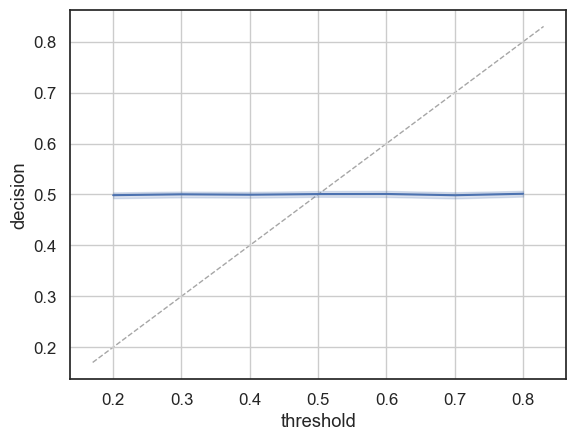

In [ ]:
fixed_parameters = {
	"threshold":0.5,
	"num_agents":6,
}
free_parameters = {
	"learning_rate":0.2,
	"bias":1,
    "individual_threshold":0.5,
	"inverse_temperature":16,
}
simulation_parameters = {
	'num_episodes':50,
	'num_rounds':100,
	'verbose':False
}

df_list = []
list_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for threshold in list_thresholds:
    fixed_parameters['threshold'] = threshold
    df = Performer.sim(
        agent_class=FairnessM1,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters,
    )
    df['threshold'] = threshold
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

ax = sns.lineplot(
    x='threshold', y='decision',
    data=df,
)
ax.grid()
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
lo, hi = min(x0, y0), max(x1, y1)
ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
